# Install

In [0]:
%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install "ray[tune]" hyperopt

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Import

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    average_precision_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
# Ray Imports
import ray
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch

# Data

In [0]:
FNOL_pdf = pd.read_excel("/Volumes/workspace/default/hastings_direct/Data_Scientist_Interview_FNOL_Data.xlsx")
FNOL_pdf[['Incurred', 'Capped Incurred']] = FNOL_pdf[['Incurred', 'Capped Incurred']].round(0).astype(int)
FNOL_pdf = FNOL_pdf.drop(columns=["Claim Number","Loss_code", "Loss_description", "TP_type_insd_pass_front", 'TP_type_pass_multi'])
region_cols = [
    'TP_region_eastang', 'TP_region_eastmid', 'TP_region_london', 
    'TP_region_north', 'TP_region_northw', 'TP_region_outerldn', 
    'TP_region_scotland', 'TP_region_southe', 'TP_region_southw', 
    'TP_region_wales', 'TP_region_westmid', 'TP_region_yorkshire'
]

# 1. Clean all regional columns and convert string placeholders to clean integers
for col in region_cols:
    FNOL_pdf[col] = pd.to_numeric(FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), errors='coerce'
    ).fillna(0).astype(int)

# 2. Total third-party headcount aggregated across all regions
FNOL_pdf['Total_Regional_TP_Count'] = FNOL_pdf[region_cols].sum(axis=1)

# 3. Define tie-aware primary region extraction logic
def get_primary_region(row):
    # Filter active regions with headcounts > 0
    active_regions = row[region_cols][row[region_cols] > 0]
    
    if active_regions.empty:
        return 'None_Recorded'
    
    max_val = active_regions.max()
    top_regions = active_regions[active_regions == max_val].index.tolist()
    
    # If a single region clearly leads in headcount
    if len(top_regions) == 1:
        return top_regions[0].replace('TP_region_', '')
    
    # If there is a headcount tie between two or more top regions
    return 'Multi_Region_Tie'

# 4. Apply the tie-aware function row-by-row
FNOL_pdf['Primary_TP_Region'] = FNOL_pdf.apply(get_primary_region, axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=region_cols)
# List of all 9 third-party type features
all_tp_type_cols = [
    'TP_type_insd_pass_back', 'TP_type_driver', 'TP_type_pass_back', 
    'TP_type_pass_front', 'TP_type_bike', 'TP_type_cyclist', 
    'TP_type_pedestrian', 'TP_type_other', 'TP_type_nk'
]

# 1. Clean all 9 columns (convert placeholders '-', 'n/k', '#' to 0)
for col in all_tp_type_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Feature 1: Total Passenger Count (Front + Back Passengers)
FNOL_pdf['Total_TP_Passenger_Count'] = (
    FNOL_pdf['TP_type_pass_front'] + FNOL_pdf['TP_type_pass_back'] + FNOL_pdf['TP_type_insd_pass_back']
)

# 3. Feature 2: Vulnerable Road User Flag (Bikes, Cyclists, Pedestrians)
FNOL_pdf['Has_Vulnerable_Road_User'] = (
    (FNOL_pdf['TP_type_bike'] > 0) | 
    (FNOL_pdf['TP_type_cyclist'] > 0) | 
    (FNOL_pdf['TP_type_pedestrian'] > 0)
).astype(int)

# 4. Feature 3: Overall TP Count (Includes ALL 9 columns, including TP_type_nk)
existing_cols = [c for c in all_tp_type_cols if c in FNOL_pdf.columns]
FNOL_pdf['Total_TP_Type_Count'] = FNOL_pdf[existing_cols].sum(axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=all_tp_type_cols)
# List of the 5 raw TP injury columns
injury_cols = ['TP_injury_whiplash', 'TP_injury_traumatic', 'TP_injury_fatality', 'TP_injury_unclear', 'TP_injury_nk']

# 1. Clean missing placeholders ('-', 'n/k', '#') across all 5 columns
for col in injury_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Define the hierarchical severity function
def determine_max_injury_tier(row):
    # Tier 4: Fatality (Highest priority)
    if row.get('TP_injury_fatality', 0) > 0:
        return 4
    # Tier 3: Traumatic / Severe Body Injury
    elif row.get('TP_injury_traumatic', 0) > 0:
        return 3
    # Tier 2: Whiplash / Soft Tissue Injury
    elif row.get('TP_injury_whiplash', 0) > 0:
        return 2
    # Tier 1: Unclear or Not Known Injury details reported
    elif row.get('TP_injury_unclear', 0) > 0 or row.get('TP_injury_nk', 0) > 0:
        return 1
    # Tier 0: No Injury Recorded
    else:
        return 0

# 3. Apply the hierarchy row-by-row
FNOL_pdf['Max_Injury_Severity_Tier'] = FNOL_pdf.apply(determine_max_injury_tier, axis=1)

# 4. Optional: Also capture total count of injured third parties
FNOL_pdf['Total_Injured_TP_Count'] = FNOL_pdf[injury_cols].sum(axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=injury_cols)
# 1. Identify your date column (replace 'date_of_loss' with your exact column name if different)
date_col = 'date_of_loss'

# 2. Convert to Pandas datetime format (handles formats like 'YYYY-MM-DD', 'DD/MM/YYYY', etc.)
FNOL_pdf[date_col] = pd.to_datetime(FNOL_pdf[date_col], errors='coerce')

# 3. Extract cyclical and temporal components
FNOL_pdf['loss_year'] = FNOL_pdf[date_col].dt.year
FNOL_pdf['loss_month'] = FNOL_pdf[date_col].dt.month
FNOL_pdf['loss_day_of_week'] = FNOL_pdf[date_col].dt.day_name()
FNOL_pdf = FNOL_pdf.drop(columns=date_col)
FNOL_pdf = FNOL_pdf.drop(columns="Incurred")
import numpy as np

# 1. Define your 10 categorical columns
cat_cols = [
    'Notifier', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Main_driver', 
    'PH_considered_TP_at_fault', 'Primary_TP_Region', 'loss_day_of_week'
]

# 2. Define missing value placeholders and casing standardizations
missing_placeholders = ['N/K', 'n/k', 'NK', 'nk', '-', '#', 'n/a', 'N/A', 'None', 'nan', '', 'Not Applicable']
casing_fixes = {'other': 'OTHER', 'Other': 'OTHER', 'unknown': 'UNKNOWN', 'Unknown': 'UNKNOWN'}

# 3. Process all 10 columns in a single loop
for col in cat_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = (
            FNOL_pdf[col]
            .astype(str)                           # Ensure string type for reliable replacement
            .str.strip()                           # Strip leading/trailing whitespace
            .replace(missing_placeholders, np.nan) # Map unknown placeholders to true NaN
            .replace(casing_fixes)                # Standardize 'Other' casing
            .astype('category')                    # Convert to category for XGBoost
        )
FNOL_pdf = FNOL_pdf[(FNOL_pdf['Notification_period'] >= 0) & (FNOL_pdf['Capped Incurred'] >= 0)]
FNOL_pdf.head()


,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,PH,22,13,Main Road,NORMAL,Y,10,OTHER,NaN,1,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,CNF,1,9,Main Road,WET,Y,18,OTHER,NaN,1,1,0,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,CNF,5,17,Main Road,WET,Y,16,Y,NaN,1,0,0,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,CNF,1,23,Main Road,NaN,Y,14,OTHER,NaN,1,1,0,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,CNF,1,48,OTHER,NaN,N,9,OTHER,NaN,1,1,0,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday


# Run the experiment with parameter tunning,choose best model and logged in mlflow 

I0000 00:00:1789242758.718817      75 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1789242759.017984      75 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1789242759.267275      75 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
2026-09-12 19:52:40,781	WARNING services.py:2248 -- WARNING: The object store is using /local_disk0/tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.86gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
I0000 00:00:1789242760.784004      75 fork_posix.cc:77] Other threads are currently calling into gRPC, skippin

+----------------------------------------------------------------------------+
| Configuration for experiment     trainable_objective_2026-09-12_19-52-44   |
+----------------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                           |
| Scheduler                        FIFOScheduler                             |
| Number of trials                 20                                        |
+----------------------------------------------------------------------------+

View detailed results here: /home/spark-e77a510a-c731-4a8a-90e9-25/ray_results/trainable_objective_2026-09-12_19-52-44
To visualize your results with TensorBoard, run: `tensorboard --logdir /local_disk0/tmp/ray/session_2026-09-12_19-52-38_700073_75/artifacts/2026-09-12_19-52-44/trainable_objective_2026-09-12_19-52-44/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-09-12 19:52:47. Total running time: 0s
Logical resource usage: 1.

2026-09-12 19:53:41,493	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-e77a510a-c731-4a8a-90e9-25/ray_results/trainable_objective_2026-09-12_19-52-44' in 0.0188s.



Trial trainable_objective_cb56f698 completed after 1 iterations at 2026-09-12 19:53:41. Total running time: 54s
+-------------------------------------------------------+
| Trial trainable_objective_cb56f698 result             |
+-------------------------------------------------------+
| checkpoint_dir_name                                   |
| time_this_iter_s                              0.85174 |
| time_total_s                                  0.85174 |
| training_iteration                                  1 |
| auprc                                         0.90744 |
| test_auprc                                    0.89622 |
| test_loss                                     0.48945 |
| train_auprc                                   0.91016 |
| train_loss                                     0.4811 |
| val_auprc                                     0.90744 |
| val_loss                                      0.48277 |
+-------------------------------------------------------+

Trial status: 20

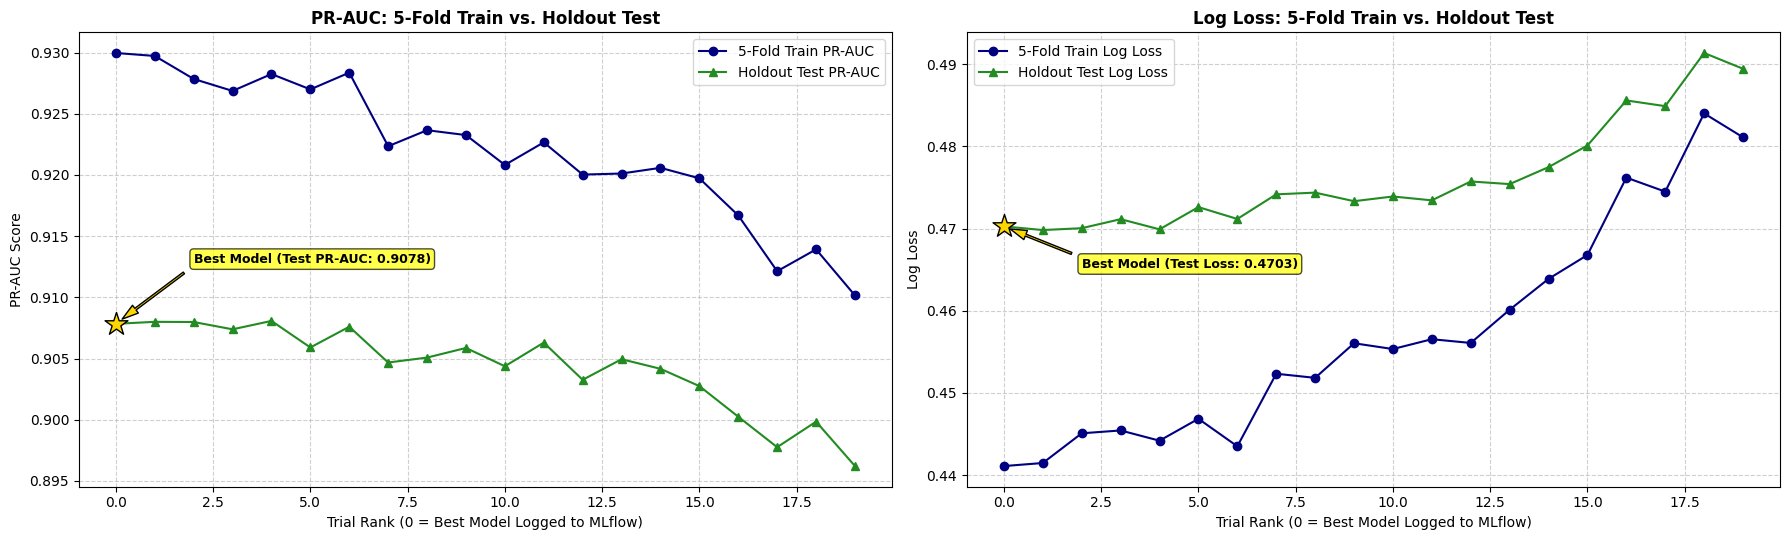

2026/09/12 19:53:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-d7f1c5e3-bdfc.cloud.databricks.com/ml/experiments/1013088755239532/models/m-5134fed5b498464791106ba484ac7557?o=7474652645564939
/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for 


Logged Best Model Run ID: 87d4d29a4e4d4b198788cfce912ed8fe
Final Holdout Test Metrics -> F1: 0.8643 | Precision: 0.7769 | Recall: 0.9737 | PR-AUC: 0.9078 | Log Loss: 0.4703


In [0]:
# 1. Define Feature Lists
categorical_features = [
    'Notifier', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile',
    'Main_driver', 'PH_considered_TP_at_fault', 'Primary_TP_Region', 'loss_day_of_week',
]

numerical_features = [
    'Notification_period', 'Inception_to_loss', 'Time_hour',
    'Vechile_registration_present', 'Incident_details_present', 'Injury_details_present',
    'Total_Regional_TP_Count', 'Total_TP_Passenger_Count', 'Has_Vulnerable_Road_User',
    'Total_TP_Type_Count', 'Max_Injury_Severity_Tier', 'Total_Injured_TP_Count',
    'loss_year', 'loss_month',
]

all_features = categorical_features + numerical_features

# 2. Extract Features and Target
X = FNOL_pdf[all_features].copy()
y = pd.Series((FNOL_pdf["Capped Incurred"] > 0).astype(int), name="target") # Binary: 1 = payout, 0 = no payout

# 3. Train / Test Split (80% Development for 5-Fold CV, 20% Holdout Test)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

y_dev = pd.Series(y_dev).reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

# 4. Pre-transform Data for Fast Ray Tune Execution
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_dev_trans = preprocessor.fit_transform(X_dev)
X_test_trans = preprocessor.transform(X_test)

# Put datasets into Ray Object Store
X_dev_ref = ray.put(X_dev_trans)
y_dev_ref = ray.put(y_dev.values)
X_test_ref = ray.put(X_test_trans)
y_test_ref = ray.put(y_test.values)

# 5. Ray Tune Objective Function with 5-Fold Stratified Cross-Validation
def trainable_objective(config):
    X_d = ray.get(X_dev_ref)
    y_d = ray.get(y_dev_ref)
    X_te = ray.get(X_test_ref)
    y_te = ray.get(y_test_ref)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_tr_auprc, cv_val_auprc = [], []
    cv_tr_loss, cv_val_loss = [], []

    for train_idx, val_idx in skf.split(X_d, y_d):
        X_tr, X_va = X_d[train_idx], X_d[val_idx]
        y_tr, y_va = y_d[train_idx], y_d[val_idx]

        model = xgb.XGBClassifier(
            max_depth=int(config["max_depth"]),
            learning_rate=config["learning_rate"],
            n_estimators=int(config["n_estimators"]),
            subsample=config["subsample"],
            colsample_bytree=config["colsample_bytree"],
            reg_alpha=config["reg_alpha"],
            reg_lambda=config["reg_lambda"],
            early_stopping_rounds=15,
            missing=np.nan,
            eval_metric='logloss',
            enable_categorical=True,
            random_state=42
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        # Fold Train Metrics
        y_tr_probs = model.predict_proba(X_tr)[:, 1]
        cv_tr_auprc.append(average_precision_score(y_tr, y_tr_probs))
        cv_tr_loss.append(log_loss(y_tr, y_tr_probs))

        # Fold Validation Metrics
        y_val_probs = model.predict_proba(X_va)[:, 1]
        cv_val_auprc.append(average_precision_score(y_va, y_val_probs))
        cv_val_loss.append(log_loss(y_va, y_val_probs))

    # Evaluate Holdout Test Set with Model Trained on Full Dev Set
    final_cv_model = xgb.XGBClassifier(
        max_depth=int(config["max_depth"]),
        learning_rate=config["learning_rate"],
        n_estimators=int(config["n_estimators"]),
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_alpha=config["reg_alpha"],
        reg_lambda=config["reg_lambda"],
        missing=np.nan,
        eval_metric='logloss',
        enable_categorical=True,
        random_state=42
    )
    final_cv_model.fit(X_d, y_d, verbose=False)
    
    y_te_probs = final_cv_model.predict_proba(X_te)[:, 1]
    te_auprc = average_precision_score(y_te, y_te_probs)
    te_loss = log_loss(y_te, y_te_probs)

    tune.report(metrics={
        "train_auprc": np.mean(cv_tr_auprc),
        "train_loss": np.mean(cv_tr_loss),
        "val_auprc": np.mean(cv_val_auprc),
        "val_loss": np.mean(cv_val_loss),
        "test_auprc": te_auprc,
        "test_loss": te_loss,
        "auprc": np.mean(cv_val_auprc)
    })

# 6. Ray Tune Search Setup
ray.init(ignore_reinit_error=True)

search_space = {
    "max_depth": tune.choice([2, 3]),
    "learning_rate": tune.choice([0.01, 0.03, 0.05]),
    "n_estimators": tune.choice([100, 150, 200]),
    "subsample": tune.choice([0.6, 0.7, 0.8]),
    "colsample_bytree": tune.choice([0.5, 0.6, 0.7]),
    "reg_alpha": tune.choice([0.5, 1.0, 5.0]),
    "reg_lambda": tune.choice([3.0, 5.0, 10.0])
}

hyperopt_search = HyperOptSearch(metric="auprc", mode="max")

tuner = tune.Tuner(
    trainable_objective,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        search_alg=hyperopt_search,
        num_samples=20,  # Updated from 30 to 20 trials
    )
)

results = tuner.fit()
best_result = results.get_best_result(metric="auprc", mode="max")
best_config = best_result.config

# 7. Generate Diagnostic Plot
results_df = results.get_dataframe()
results_df = results_df.sort_values(by="val_auprc", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

# Plot 1: 5-Fold Train vs Holdout Test PR-AUC
axes[0].plot(results_df.index, results_df["train_auprc"], marker='o', label="5-Fold Train PR-AUC", color='navy')
axes[0].plot(results_df.index, results_df["test_auprc"], marker='^', label="Holdout Test PR-AUC", color='forestgreen')
axes[0].set_title("PR-AUC: 5-Fold Train vs. Holdout Test", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Trial Rank (0 = Best Model Logged to MLflow)")
axes[0].set_ylabel("PR-AUC Score")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Plot 2: 5-Fold Train vs Holdout Test Log Loss
axes[1].plot(results_df.index, results_df["train_loss"], marker='o', label="5-Fold Train Log Loss", color='navy')
axes[1].plot(results_df.index, results_df["test_loss"], marker='^', label="Holdout Test Log Loss", color='forestgreen')
axes[1].set_title("Log Loss: 5-Fold Train vs. Holdout Test", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Trial Rank (0 = Best Model Logged to MLflow)")
axes[1].set_ylabel("Log Loss")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# Annotate Best Model (Rank 0)
best_metrics = {
    0: ("test_auprc", "Test PR-AUC"),
    1: ("test_loss", "Test Loss")
}

for col, (metric_key, label_str) in best_metrics.items():
    ax = axes[col]
    y_val = results_df.loc[0, metric_key]
    
    ax.scatter(0, y_val, color='gold', s=300, zorder=6, edgecolors='black', marker='*', label="Best Model (MLflow)")
    
    ax.annotate(
        f'Best Model ({label_str}: {y_val:.4f})', 
        xy=(0, y_val), 
        xytext=(2, y_val + (0.005 if "loss" not in metric_key else -0.005)),
        arrowprops=dict(facecolor='gold', edgecolor='black', shrink=0.08, width=1.5, headwidth=7),
        fontsize=9, 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7)
    )

plt.tight_layout()
plot_filename = "cv_train_val_test_overfitting_analysis.png"
plt.savefig(plot_filename)
plt.show()

# 8. Re-train Final Model on Full Development Set & Log to MLflow
mlflow.set_experiment("/Users/" + spark.sql("SELECT current_user()").collect()[0][0] + "/XGBoost_FNOL_two_stages_modeling")

with mlflow.start_run(run_name="XGBoost_first_payout_Best_Model") as run:
    
    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            max_depth=int(best_config["max_depth"]),
            learning_rate=best_config["learning_rate"],
            n_estimators=int(best_config["n_estimators"]),
            subsample=best_config["subsample"],
            colsample_bytree=best_config["colsample_bytree"],
            reg_alpha=best_config["reg_alpha"],
            reg_lambda=best_config["reg_lambda"],
            missing=np.nan,
            eval_metric='logloss',
            enable_categorical=True,
            random_state=42
        ))
    ])
    
    best_pipeline.fit(X_dev, y_dev)
    
    y_test_pred = best_pipeline.predict(X_test)
    y_test_probs = best_pipeline.predict_proba(X_test)[:, 1]
    
    final_f1 = f1_score(y_test, y_test_pred)
    final_precision = precision_score(y_test, y_test_pred)
    final_recall = recall_score(y_test, y_test_pred)
    final_auprc = average_precision_score(y_test, y_test_probs)
    final_loss = log_loss(y_test, y_test_probs)
    
    mlflow.log_params(best_config)
    mlflow.log_metrics({
        "test_f1_score": final_f1,
        "test_precision": final_precision,
        "test_recall": final_recall,
        "test_auprc": final_auprc,
        "test_log_loss": final_loss
    })
    
    mlflow.log_artifact(plot_filename)
    
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="xgboost_fnol_pipeline_best",
        input_example=X_dev.iloc[:5]
    )

    print(f"\nLogged Best Model Run ID: {run.info.run_id}")
    print(
        f"Final Holdout Test Metrics -> "
        f"F1: {final_f1:.4f} | "
        f"Precision: {final_precision:.4f} | "
        f"Recall: {final_recall:.4f} | "
        f"PR-AUC: {final_auprc:.4f} | "
        f"Log Loss: {final_loss:.4f}"
    )

Loading model from: runs:/87d4d29a4e4d4b198788cfce912ed8fe/xgboost_fnol_pipeline_best



     MODEL PERFORMANCE EVALUATION
F1 Score:     0.8643
PR-AUC:       0.9078
Log Loss:     0.4703

Detailed Classification Report:
               precision    recall  f1-score   support

No Payout (0)       0.43      0.07      0.11       352
   Payout (1)       0.78      0.97      0.86      1177

     accuracy                           0.76      1529
    macro avg       0.60      0.52      0.49      1529
 weighted avg       0.70      0.76      0.69      1529


     TOP 15 FEATURE IMPORTANCES
                        Feature  Importance
       Max_Injury_Severity_Tier    0.165221
               Vehicle_mobile_N    0.100505
               Vehicle_mobile_Y    0.067986
        Total_Regional_TP_Count    0.052471
    PH_considered_TP_at_fault_N    0.044818
Primary_TP_Region_None_Recorded    0.043371
            Total_TP_Type_Count    0.036131
                 Notifier_OTHER    0.024644
                      loss_year    0.022704
                    Notifier_PH    0.021927
Location_of_inciden

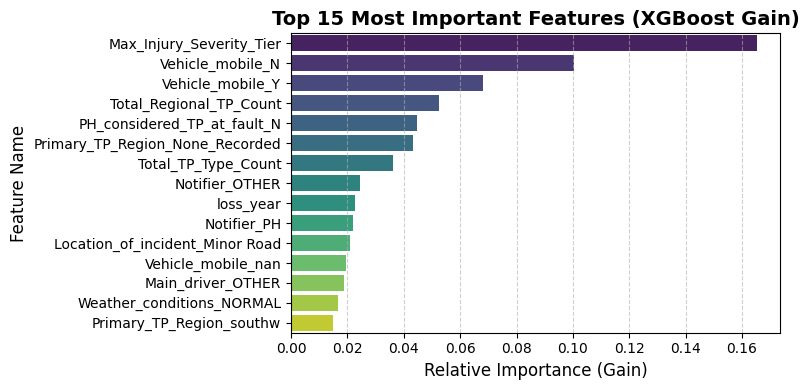

In [0]:
# -------------------------------------------------------------------------
# 1. Load the Model from MLflow using Run ID
# -------------------------------------------------------------------------
run_id = "87d4d29a4e4d4b198788cfce912ed8fe"  # Replace with your actual Run ID string
artifact_path = (
    "xgboost_fnol_pipeline_best"  # Match the artifact path logged during training
)

model_uri = f"runs:/{run_id}/{artifact_path}"
print(f"Loading model from: {model_uri}")

# Load the full Scikit-Learn Pipeline (OneHotEncoder + XGBoost)
loaded_pipeline = mlflow.sklearn.load_model(model_uri)

# -------------------------------------------------------------------------
# 2. Predict on Data and Evaluate Performance
# -------------------------------------------------------------------------
# Pass raw X_test directly - the pipeline handles feature transformations
y_pred = loaded_pipeline.predict(X_test)
y_pred_probs = loaded_pipeline.predict_proba(X_test)[:, 1]

# Calculate Metrics
f1 = f1_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_pred_probs)
loss = log_loss(y_test, y_pred_probs)

print("\n" + "=" * 40)
print("     MODEL PERFORMANCE EVALUATION")
print("=" * 40)
print(f"F1 Score:     {f1:.4f}")
print(f"PR-AUC:       {auprc:.4f}")
print(f"Log Loss:     {loss:.4f}")
print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["No Payout (0)", "Payout (1)"]
    )
)

# -------------------------------------------------------------------------
# 3. Extract Feature Importances with True Feature Names
# -------------------------------------------------------------------------
# Extract fitted steps from the pipeline
preprocessor = loaded_pipeline.named_steps["preprocessor"]
xgb_model = loaded_pipeline.named_steps["classifier"]

# Get encoded categorical feature names from OneHotEncoder
cat_encoder = preprocessor.named_transformers_["cat"]
encoded_cat_features = list(
    cat_encoder.get_feature_names_out(categorical_features)
)

# Combine with numerical features in exact pipeline processing order
feature_names = encoded_cat_features + numerical_features

# Extract gain-based feature importances from XGBoost
importances = xgb_model.feature_importances_

# Construct DataFrame
feature_imp_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 40)
print("     TOP 15 FEATURE IMPORTANCES")
print("=" * 40)
print(feature_imp_df.head(15).to_string(index=False))

# -------------------------------------------------------------------------
# 4. Plot Feature Importances
# -------------------------------------------------------------------------
top_15_df = feature_imp_df.head(15)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_15_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("Top 15 Most Important Features (XGBoost Gain)", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance (Gain)", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Performance the model on data

     FULL DATASET PERFORMANCE EVALUATION
Total Claims Analyzed: 7,641
Overall F1-Score:      0.8689
Overall PR-AUC:        0.9255
Overall Log Loss:      0.4465

               precision    recall  f1-score   support

No Payout (0)       0.54      0.09      0.16      1758
   Payout (1)       0.78      0.98      0.87      5883

     accuracy                           0.77      7641
    macro avg       0.66      0.54      0.51      7641
 weighted avg       0.73      0.77      0.71      7641



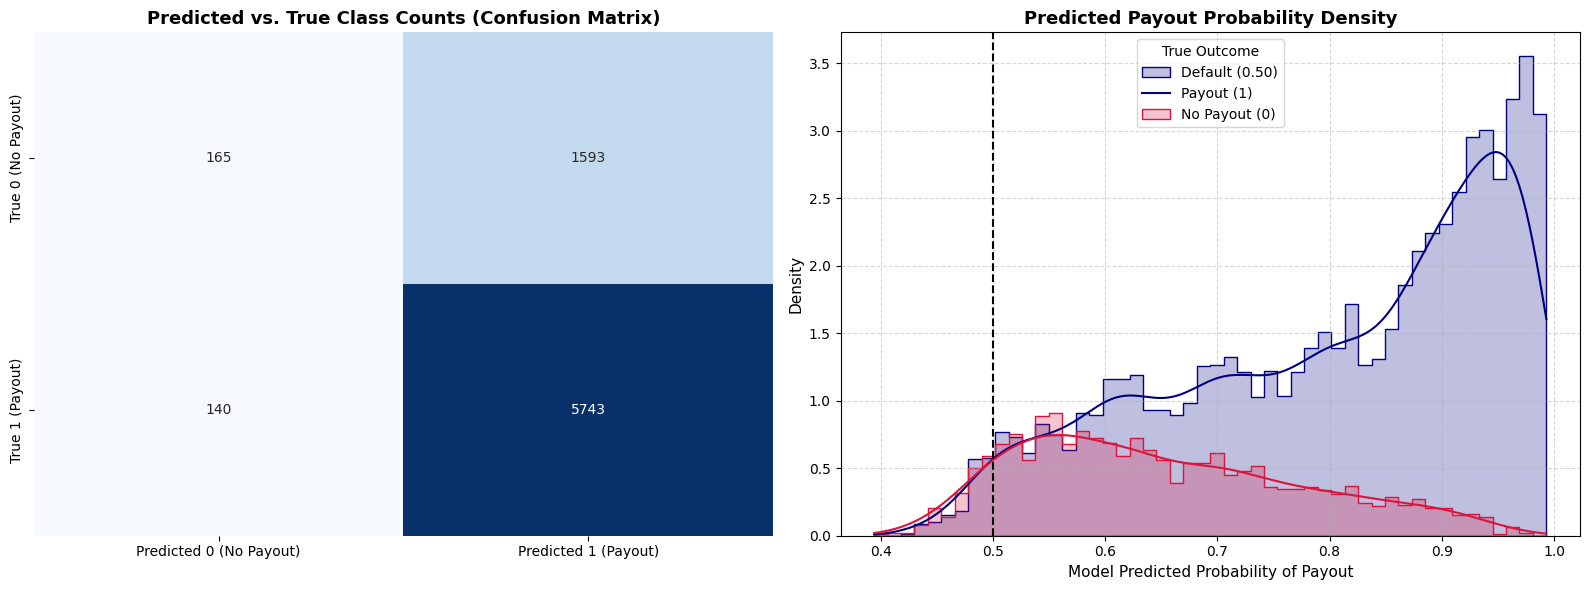

In [0]:
# 1. Prepare Full Dataset
X_full = FNOL_pdf[all_features].copy()
y_full = (FNOL_pdf["Capped Incurred"] > 0).astype(int)

# 2. Generate Predictions on Full Dataset
y_full_pred = loaded_pipeline.predict(X_full)
y_full_probs = loaded_pipeline.predict_proba(X_full)[:, 1]

# 3. Compute Metrics on Full Dataset
full_f1 = f1_score(y_full, y_full_pred)
full_auprc = average_precision_score(y_full, y_full_probs)
full_loss = log_loss(y_full, y_full_probs)

print("=" * 45)
print("     FULL DATASET PERFORMANCE EVALUATION")
print("=" * 45)
print(f"Total Claims Analyzed: {len(y_full):,}")
print(f"Overall F1-Score:      {full_f1:.4f}")
print(f"Overall PR-AUC:        {full_auprc:.4f}")
print(f"Overall Log Loss:      {full_loss:.4f}\n")
print(classification_report(y_full, y_full_pred, target_names=["No Payout (0)", "Payout (1)"]))

# 4. Plot Predicted vs. True Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix (Predicted Class vs. True Class)
cm = confusion_matrix(y_full, y_full_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    ax=axes[0],
    xticklabels=["Predicted 0 (No Payout)", "Predicted 1 (Payout)"],
    yticklabels=["True 0 (No Payout)", "True 1 (Payout)"],
    cbar=False
)
axes[0].set_title("Predicted vs. True Class Counts (Confusion Matrix)", fontsize=13, fontweight="bold")

# Plot B: Predicted Probability Distribution by True Class
sns.histplot(
    x=y_full_probs, 
    hue=y_full, 
    bins=50, 
    kde=True, 
    ax=axes[1],
    palette={0: "crimson", 1: "navy"},
    element="step",
    stat="density"
)
axes[1].axvline(0.5, color="black", linestyle="--", label="Default Decision Threshold (0.50)")
axes[1].set_title("Predicted Payout Probability Density", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Model Predicted Probability of Payout", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].legend(title="True Outcome", labels=["Default (0.50)", "Payout (1)", "No Payout (0)"])
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Attach Predictions to the Original DataFrame
FNOL_pdf_scored = FNOL_pdf.copy()
FNOL_pdf_scored["predicted_payout_class"] = y_full_pred
FNOL_pdf_scored["predicted_payout_probability"] = y_full_probs

     FULL DATASET PERFORMANCE EVALUATION
Total Claims Analyzed: 7,641
Overall F1-Score:      0.8689
Overall PR-AUC:        0.9255
Overall Log Loss:      0.4465

               precision    recall  f1-score   support

No Payout (0)       0.54      0.09      0.16      1758
   Payout (1)       0.78      0.98      0.87      5883

     accuracy                           0.77      7641
    macro avg       0.66      0.54      0.51      7641
 weighted avg       0.73      0.77      0.71      7641



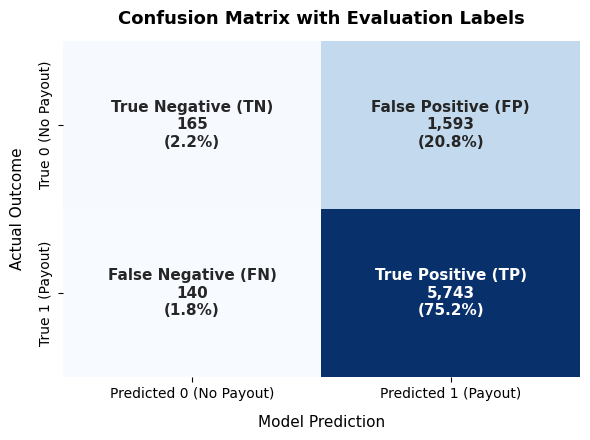

In [0]:
# 1. Prepare Full Dataset
X_full = FNOL_pdf[all_features].copy()
y_full = (FNOL_pdf["Capped Incurred"] > 0).astype(int)

# 2. Generate Predictions on Full Dataset
y_full_pred = loaded_pipeline.predict(X_full)
y_full_probs = loaded_pipeline.predict_proba(X_full)[:, 1]

# 3. Compute Metrics on Full Dataset
full_f1 = f1_score(y_full, y_full_pred)
full_auprc = average_precision_score(y_full, y_full_probs)
full_loss = log_loss(y_full, y_full_probs)

print("=" * 45)
print("     FULL DATASET PERFORMANCE EVALUATION")
print("=" * 45)
print(f"Total Claims Analyzed: {len(y_full):,}")
print(f"Overall F1-Score:      {full_f1:.4f}")
print(f"Overall PR-AUC:        {full_auprc:.4f}")
print(f"Overall Log Loss:      {full_loss:.4f}\n")
print(classification_report(y_full, y_full_pred, target_names=["No Payout (0)", "Payout (1)"]))

# 4. Enhanced Confusion Matrix Plot
cm = confusion_matrix(y_full, y_full_pred)
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

# Custom annotations showing metric label, count, and percentage
labels = [
    f"True Negative (TN)\n{tn:,}\n({tn/total:.1%})",
    f"False Positive (FP)\n{fp:,}\n({fp/total:.1%})",
    f"False Negative (FN)\n{fn:,}\n({fn/total:.1%})",
    f"True Positive (TP)\n{tp:,}\n({tp/total:.1%})"
]
annot_matrix = np.array(labels).reshape(2, 2)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm, 
    annot=annot_matrix, 
    fmt="", 
    cmap="Blues", 
    cbar=False,
    annot_kws={"size": 11, "weight": "bold"},
    xticklabels=["Predicted 0 (No Payout)", "Predicted 1 (Payout)"],
    yticklabels=["True 0 (No Payout)", "True 1 (Payout)"]
)

plt.title("Confusion Matrix with Evaluation Labels", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Model Prediction", fontsize=11, labelpad=10)
plt.ylabel("Actual Outcome", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

# 5. Attach Predictions to the Original DataFrame
FNOL_pdf_scored = FNOL_pdf.copy()
FNOL_pdf_scored["predicted_payout_class"] = y_full_pred
FNOL_pdf_scored["predicted_payout_probability"] = y_full_probs